In [122]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [123]:
# Load MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Keep only digits 0 and 1
train_filter = (y_train == 0) | (y_train == 1)
test_filter = (y_test == 0) | (y_test == 1)

x_train = x_train[train_filter]
y_train = y_train[train_filter]

x_test = x_test[test_filter]
y_test = y_test[test_filter]

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)
print("Classes:", np.unique(y_train))

Training images: (12665, 28, 28)
Testing images: (2115, 28, 28)
Classes: [0 1]


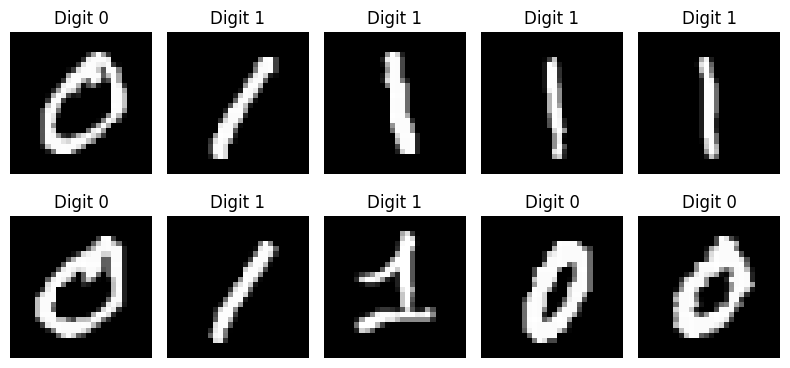

In [124]:
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title("Digit " + str(y_train[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [125]:
x_train_scaled = x_train.astype("float32") / 255.0
x_test_scaled = x_test.astype("float32") / 255.0

# Flatten 28x28 images into 784 features
x_train_flat = x_train_scaled.reshape(len(x_train_scaled), -1)
x_test_flat = x_test_scaled.reshape(len(x_test_scaled), -1)

print("Flattened image size:", x_train_flat.shape[1])


Flattened image size: 784


In [126]:
classifier = LogisticRegression(
    max_iter=100,
    solver="lbfgs"
)

classifier.fit(x_train_flat, y_train)

print("Discriminative model training completed.")

Discriminative model training completed.


In [127]:
predicted_digits = classifier.predict(x_test_flat)

accuracy = accuracy_score(y_test, predicted_digits)

print("Discriminative Model Accuracy:", round(accuracy * 100, 2), "%")

Discriminative Model Accuracy: 99.95 %


In [128]:
cm = confusion_matrix(y_test, predicted_digits)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 979    1]
 [   0 1135]]


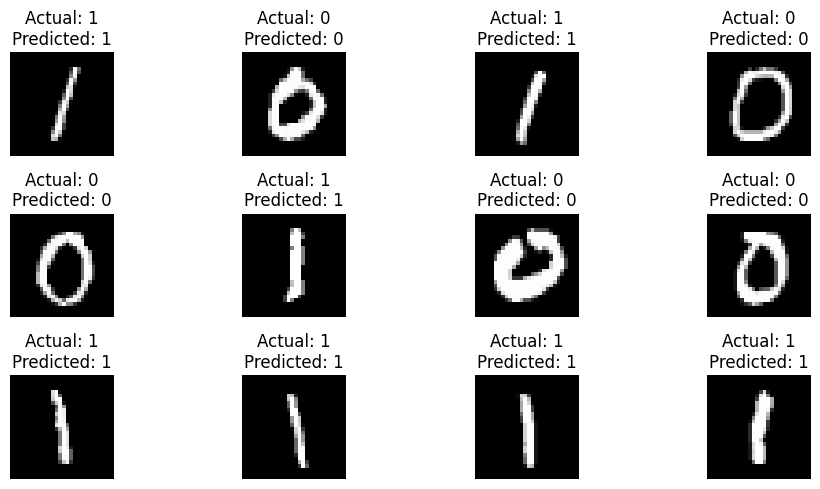

In [129]:
plt.figure(figsize=(10, 5))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title("Actual: " + str(y_test[i]) +
              "\nPredicted: " + str(predicted_digits[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [130]:
# Use all 0 and 1 images together
autoencoder_data = x_train_flat

print("Data used by Autoencoder:", autoencoder_data.shape)

Data used by Autoencoder: (12665, 784)


In [131]:
input_layer = Input(shape=(784,))

# Encoder
encoded = Dense(128, activation="relu")(input_layer)
encoded = Dense(32, activation="relu")(encoded)

# Decoder
decoded = Dense(128, activation="relu")(encoded)
decoded = Dense(784, activation="sigmoid")(decoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

autoencoder.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

In [132]:
history = autoencoder.fit(
    autoencoder_data,
    autoencoder_data,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.2766 - val_loss: 0.1512
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1340 - val_loss: 0.1207
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1150 - val_loss: 0.1080
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1051 - val_loss: 0.1002
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0972 - val_loss: 0.0943
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0919 - val_loss: 0.0898
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0883 - val_loss: 0.0865
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0853 - val_loss: 0.0843
Epoch 9/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0829 - val_loss: 0.0827
Epoch 10/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0810 - val_loss: 0.0805


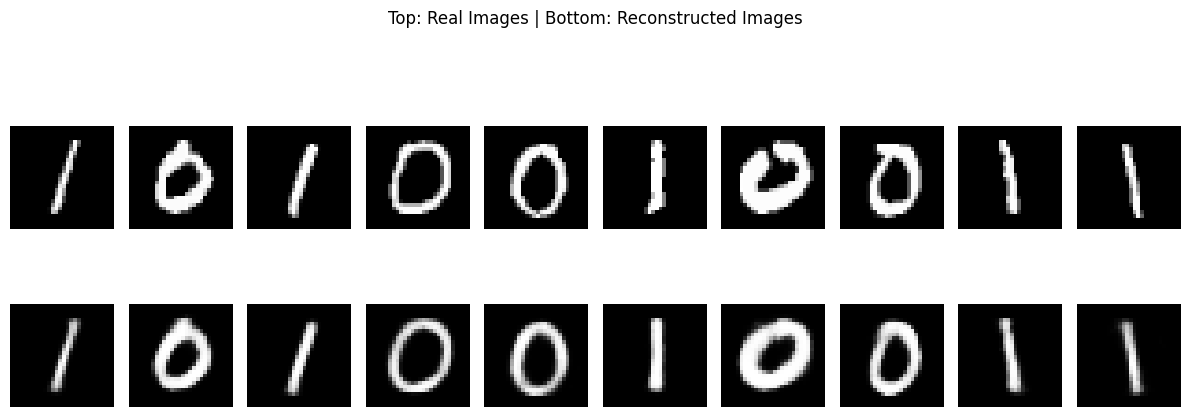

In [133]:
reconstructed = autoencoder.predict(x_test_flat[:10], verbose=0)

plt.figure(figsize=(12, 5))

for i in range(10):
    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Top: Real Images | Bottom: Reconstructed Images")
plt.tight_layout()
plt.show()

In [134]:
# Create a separate encoder and decoder
encoder = Model(input_layer, encoded)

latent_input = Input(shape=(32,))
decoder_layer1 = autoencoder.layers[-2]
decoder_layer2 = autoencoder.layers[-1]

decoder_output = decoder_layer2(decoder_layer1(latent_input))

decoder = Model(latent_input, decoder_output)

In [119]:
# Get latent representations of some training images
latent_values = encoder.predict(x_train_flat, verbose=0)

# Calculate the average and variation of the latent features
latent_mean = np.mean(latent_values, axis=0)
latent_std = np.std(latent_values, axis=0)

# Create new random latent points
np.random.seed(7)

new_latent_points = (
    latent_mean +
    np.random.normal(
        0,
        latent_std * 0.7,
        size=(12, 32)
    )
)

generated_digits = decoder.predict(new_latent_points, verbose=0)

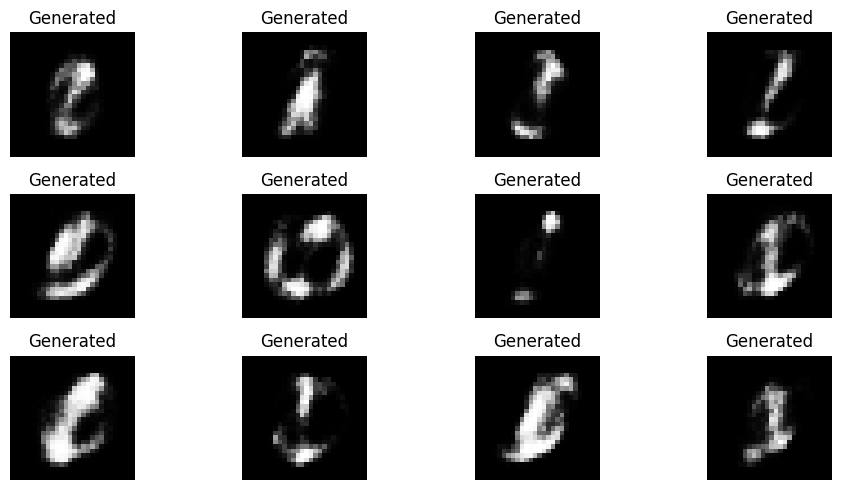

In [120]:
plt.figure(figsize=(10, 5))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(
        generated_digits[i].reshape(28, 28),
        cmap="gray"
    )
    plt.title("Generated")
    plt.axis("off")

plt.tight_layout()
plt.show()

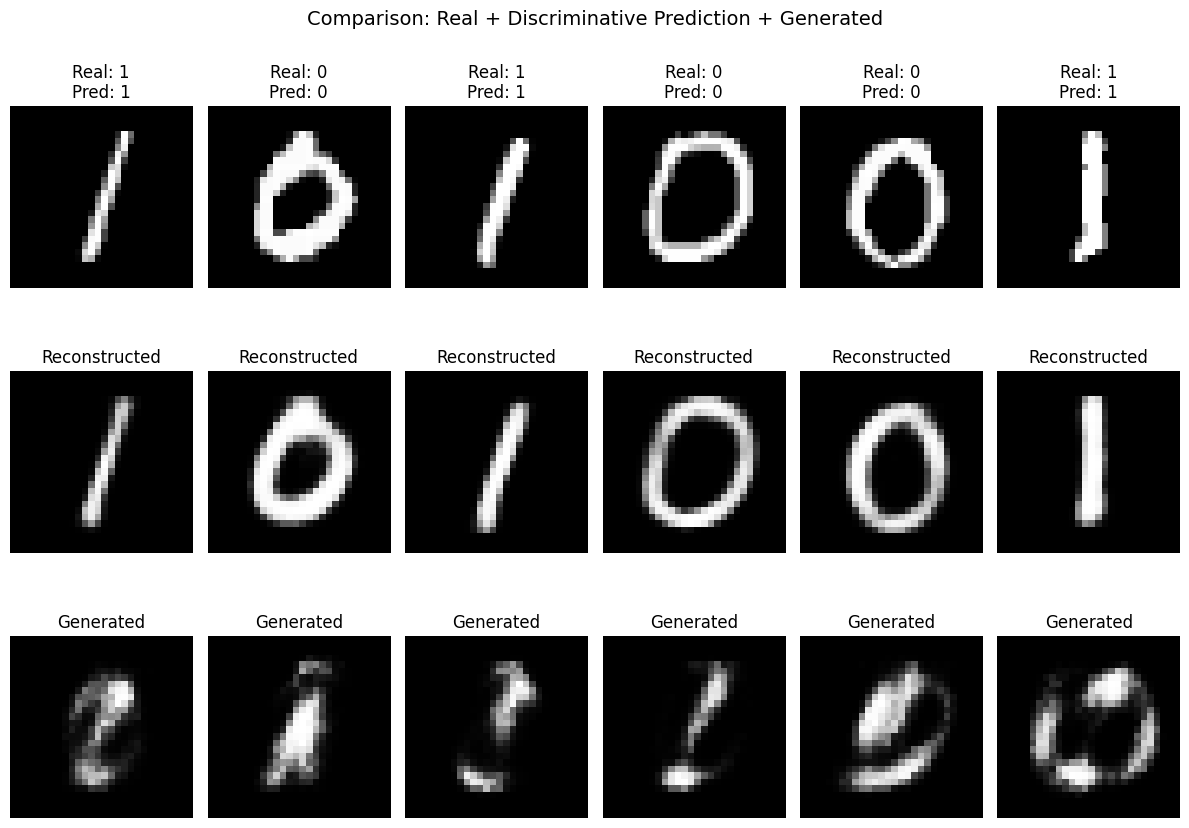

In [121]:
plt.figure(figsize=(12, 9))

# Real images with predictions
for i in range(6):
    plt.subplot(3, 6, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(
        f"Real: {y_test[i]}\nPred: {predicted_digits[i]}"
    )
    plt.axis("off")

# Reconstructed images
for i in range(6):
    plt.subplot(3, 6, i + 7)
    plt.imshow(
        reconstructed[i].reshape(28, 28),
        cmap="gray"
    )
    plt.title("Reconstructed")
    plt.axis("off")

# Generated images
for i in range(6):
    plt.subplot(3, 6, i + 13)
    plt.imshow(
        generated_digits[i].reshape(28, 28),
        cmap="gray"
    )
    plt.title("Generated")
    plt.axis("off")

plt.suptitle(
    "Comparison: Real + Discriminative Prediction + Generated",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [135]:
print("========== MODEL COMPARISON ==========")

print("Discriminative Model:")
print("Purpose: Classify digits as 0 or 1")
print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nGenerative Model:")
print("Purpose: Learn the patterns of digit images")
print("Model: Autoencoder")

print("\nMain Difference:")
print("Discriminative model learns the boundary between classes.")
print("Generative model learns useful patterns from the input images.")

========== MODEL COMPARISON ==========
Discriminative Model:
Purpose: Classify digits as 0 or 1
Accuracy: 99.95 %

Generative Model:
Purpose: Learn the patterns of digit images
Model: Autoencoder

Main Difference:
Discriminative model learns the boundary between classes.
Generative model learns useful patterns from the input images.
